<a href="https://colab.research.google.com/github/lgplorea/EjerciciosPython/blob/main/Copia_de_PruebaEjercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

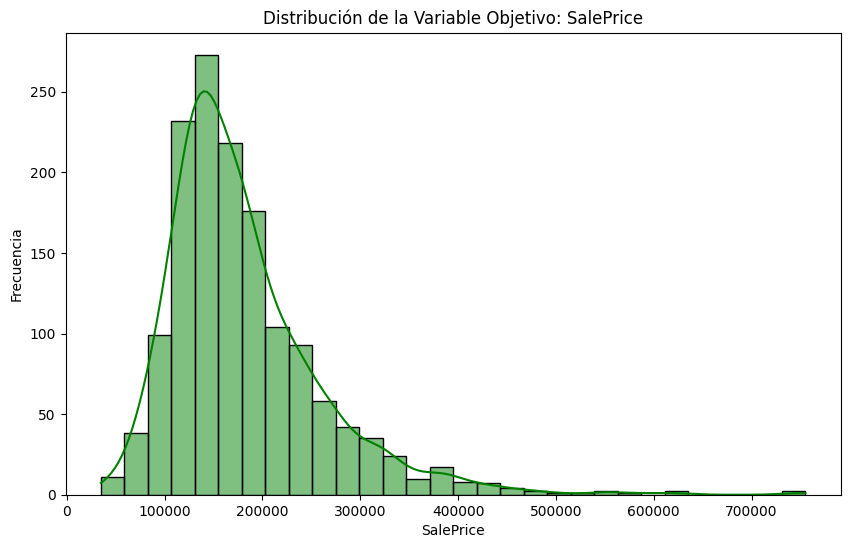

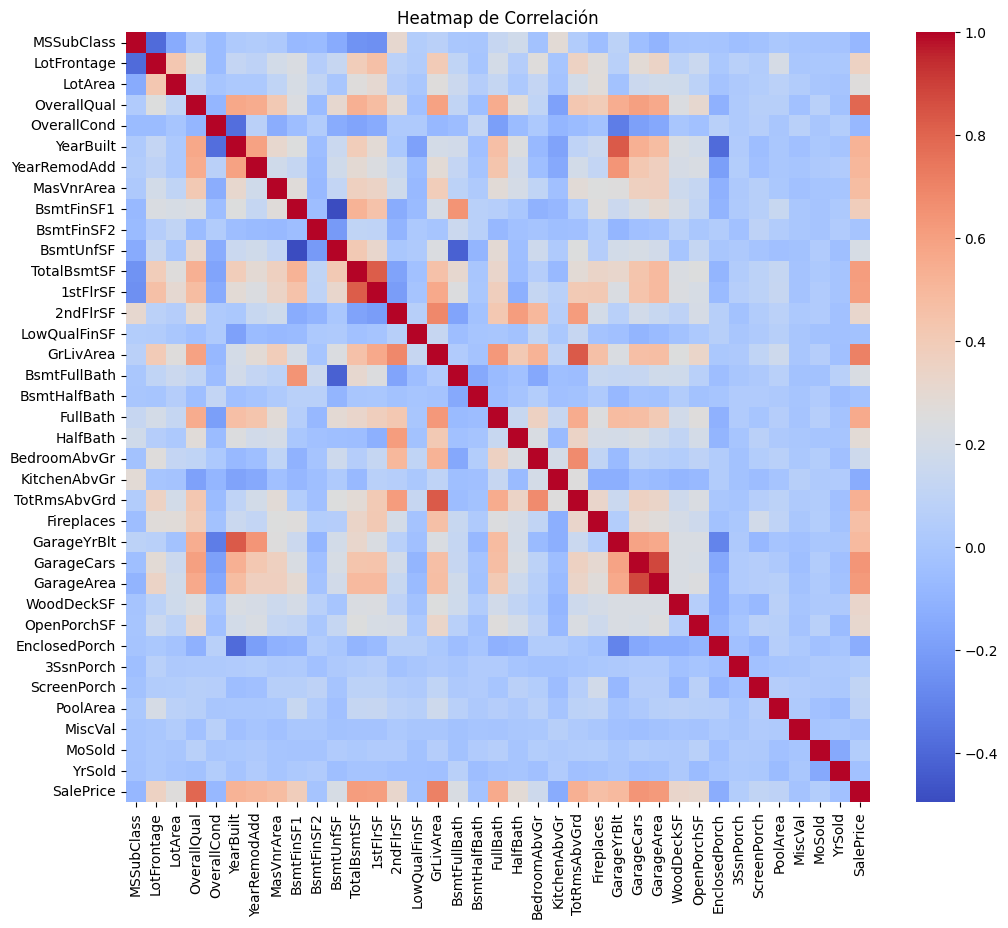

----------------------------------------
Métricas de Evaluación para la Entrega:
----------------------------------------
Coeficiente de Determinación ($R^2$): 0.6557
Error Absoluto Medio (MAE): 20236.4061
----------------------------------------


In [ ]:
# =====================================================================
# [X] Base de datos recomendada: Importar el dataset de Kaggle
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Cargar el archivo descargado de Kaggle
df = pd.read_csv('train (1).csv')

# Eliminar la columna 'Id' ya que es solo un identificador y no aporta valor predictivo
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# =====================================================================
# [X] Gráfico de distribución de la variable objetivo (SalePrice) creado
# =====================================================================
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='green', bins=30)
plt.title('Distribución de la Variable Objetivo: SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.show()

# =====================================================================
# [X] Heatmap de correlación generado
# =====================================================================
# Calculamos la correlación solo para las variables numéricas
plt.figure(figsize=(12, 10))
matriz_correlacion = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de Correlación')
plt.show()
# Nota para el reporte: Busca las variables que tengan los colores más oscuros
# (rojo o azul intenso) en la fila/columna de 'SalePrice' para interpretarlas.

# =====================================================================
# [X] Tratamiento de valores nulos completado (imputación)
# =====================================================================
# Imputamos variables numéricas con la mediana
cols_numericas = df.select_dtypes(include=[np.number]).columns
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

# Imputamos variables categóricas con el valor más frecuente (la moda)
cols_categoricas = df.select_dtypes(include=['object']).columns
for col in cols_categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

# =====================================================================
# [X] Conversión de variables categóricas (One-Hot Encoding)
# =====================================================================
# pd.get_dummies convierte las columnas categóricas en múltiples columnas binarias (0 y 1)
df_procesado = pd.get_dummies(df, drop_first=True)

# Separar las características (X) y la variable objetivo (y)
# Para ver cómo las características de una vivienda pueden predecir su precio de venta
X = df_procesado.drop('SalePrice', axis=1)
y = df_procesado['SalePrice']

# =====================================================================
# [X] División del conjunto de datos en Train/Test (proporción 80/20)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# =====================================================================
# [X] Modelo de Regresión Lineal entrenado sin errores de compilación
# =====================================================================
modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)
#fit para entrenar el modelo de regresión lineal (modelo_rl)

# Generar las predicciones con el conjunto de prueba
# Los datos que le damos son solo x (características de las casas)
y_pred = modelo_rl.predict(X_test)

# =====================================================================
# [X] Métricas de evaluación R^2 y MAE calculadas y anotadas
# =====================================================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("-" * 40)
print("Métricas de Evaluación para la Entrega:")
print("-" * 40)
print(f"Coeficiente de Determinación ($R^2$): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print("-" * 40)